# 10 — Model Comparison: M1, M2, M3, M4, M5

Final comparison of all models across 5-fold cross-validation:

| Model | Description |
|-------|-------------|
| M1 | Facial BiLSTM — camera only |
| M2 | Telemetry LSTM — CAN only |
| M3 | Cross-Modal Attention Fusion — earlier fusion attempt |
| M4 | Real-Time BiLSTM / Live features (if available) |
| **M5** | **YOLOv8-cls — Image-based baseline (this thesis baseline)** |

Plots:
- Side-by-side accuracy and F1 comparison
- Individual fold breakdown
- Aggregate confusion matrices
- (If available) M3 attention weight visualisation


In [1]:
import sys, warnings, json, os
from pathlib import Path
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

from utils.helpers import plot_model_comparison, plot_confusion_matrix

RESULTS_DIR = ROOT / 'results' / 'reports'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['Alert', 'LowVigilant', 'Drowsy']
print('Ready.')

Ready.


In [2]:
# ── Load results from JSON (saved by training notebooks) ─────────────────────
def _load_or_placeholder(path, model_name):
    try:
        with open(path) as f:
            raw = json.load(f)
    except FileNotFoundError:
        print(f'Warning: {path.name} not found — using placeholder for {model_name}.')
        return {
            'model_name': model_name,
            'mean_acc': 0.0, 'std_acc': 0.0,
            'mean_f1' : 0.0, 'std_f1' : 0.0,
            'folds'   : [{'accuracy': 0., 'macro_f1': 0.}] * 5,
        }

    # Normalise: real JSON uses 'model'; fold metrics are nested under 'metrics'
    raw['model_name'] = raw.get('model_name') or raw.get('model', model_name)
    for fold in raw.get('folds', []):
        metrics = fold.get('metrics', {})
        fold.setdefault('accuracy',  metrics.get('accuracy',  0.0))
        fold.setdefault('macro_f1',  metrics.get('macro_f1',  0.0))
        # y_true / y_pred may not be stored — that is fine
    return raw

m1_results = _load_or_placeholder(RESULTS_DIR / 'M1_results.json', 'M1')
m2_results = _load_or_placeholder(RESULTS_DIR / 'M2_results.json', 'M2')
m3_results = _load_or_placeholder(RESULTS_DIR / 'M3_results.json', 'M3')
# M4 may not have been produced; load if present (placeholder otherwise)
m4_results = _load_or_placeholder(RESULTS_DIR / 'M4_results.json', 'M4')
m5_results = _load_or_placeholder(RESULTS_DIR / 'M5_results.json', 'M5')

# Build results list dynamically so notebook adapts to available models
all_results = [m1_results, m2_results, m3_results]
for r in (m4_results, m5_results):
    # include only if file existed or explicit placeholder (keeps ordering)
    all_results.append(r)

print('Loaded:')
for r in all_results:
    print(f"  {r['model_name']:>3}  acc={r['mean_acc']:.4f}±{r['std_acc']:.4f}" \
          f"  f1={r['mean_f1']:.4f}±{r['std_f1']:.4f}")


Loaded:
   M1  acc=0.3913±0.1157  f1=0.3475±0.0919
   M2  acc=0.3867±0.0401  f1=0.3386±0.0267
   M3  acc=0.3992±0.0984  f1=0.3778±0.0934
   M4  acc=0.0000±0.0000  f1=0.0000±0.0000
   M5  acc=0.5451±0.1000  f1=0.4439±0.0745


In [3]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for r in all_results:
    rows.append({
        'Model'       : r['model_name'],
        'Accuracy'    : r['mean_acc'],
        'Acc ± std'   : f"{r['mean_acc']:.4f} ± {r['std_acc']:.4f}",
        'Macro-F1'    : r['mean_f1'],
        'F1 ± std'    : f"{r['mean_f1']:.4f} ± {r['std_f1']:.4f}",
    })

summary_df = pd.DataFrame(rows).set_index('Model')
summary_df

,Accuracy,Acc ± std,Macro-F1,F1 ± std
Model,,,,
M1,0.391325,0.3913 ± 0.1157,0.347546,0.3475 ± 0.0919
M2,0.386656,0.3867 ± 0.0401,0.338597,0.3386 ± 0.0267
M3,0.399226,0.3992 ± 0.0984,0.377790,0.3778 ± 0.0934
M4,0.000000,0.0000 ± 0.0000,0.000000,0.0000 ± 0.0000
M5,0.545115,0.5451 ± 0.1000,0.443906,0.4439 ± 0.0745


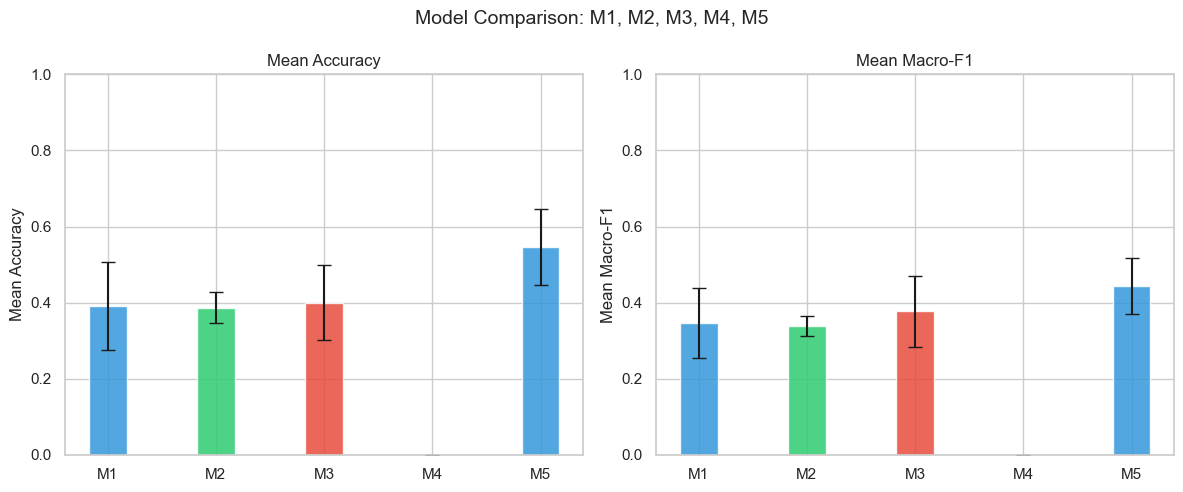

In [4]:
# ── Side-by-side model comparison bar chart ───────────────────────────────────
labels  = [r['model_name'] for r in all_results]
accs    = [r['mean_acc']   for r in all_results]
f1s     = [r['mean_f1']    for r in all_results]
acc_std = [r['std_acc']    for r in all_results]
f1_std  = [r['std_f1']     for r in all_results]

x      = np.arange(len(labels))
width  = 0.35
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'][:len(labels)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, vals, stds, title in zip(
    axes,
    [accs, f1s],
    [acc_std, f1_std],
    ['Mean Accuracy', 'Mean Macro-F1'],
):
    bars = ax.bar(x, vals, width, yerr=stds, capsize=5,
                  color=colors, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    ax.set_ylabel(title)
    ax.set_title(title)

plt.suptitle('Model Comparison: ' + ', '.join(labels), fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


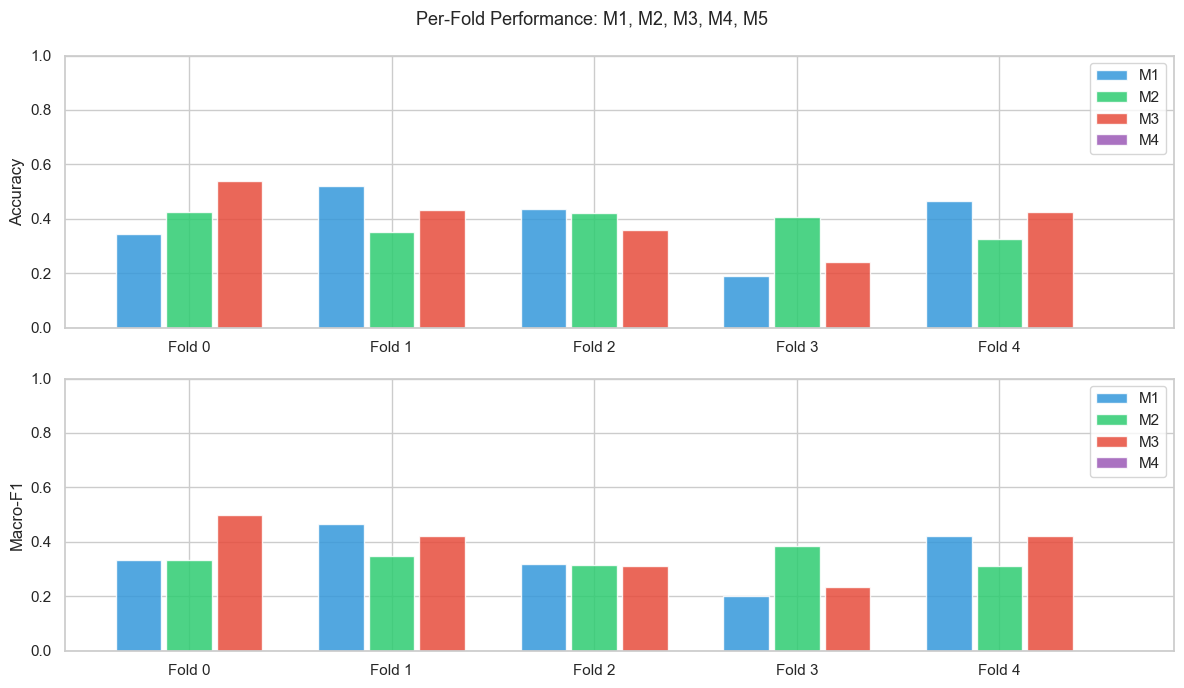

In [5]:
# ── Per-fold breakdown across models ──────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
x      = np.arange(5)
width  = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'][:len(all_results)]
labels = [r['model_name'] for r in all_results]

for ax, metric, ylabel in zip(axes, ['accuracy', 'macro_f1'], ['Accuracy', 'Macro-F1']):
    for i, (r, color, label) in enumerate(zip(all_results, colors, labels)):
        vals = [f.get(metric, 0) for f in r['folds']]
        bars = ax.bar(x + i*width, vals, width*0.9, label=label, color=color, alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'Fold {i}' for i in range(5)])
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.set_ylim(0, 1)

plt.suptitle('Per-Fold Performance: ' + ', '.join(labels), fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_fold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


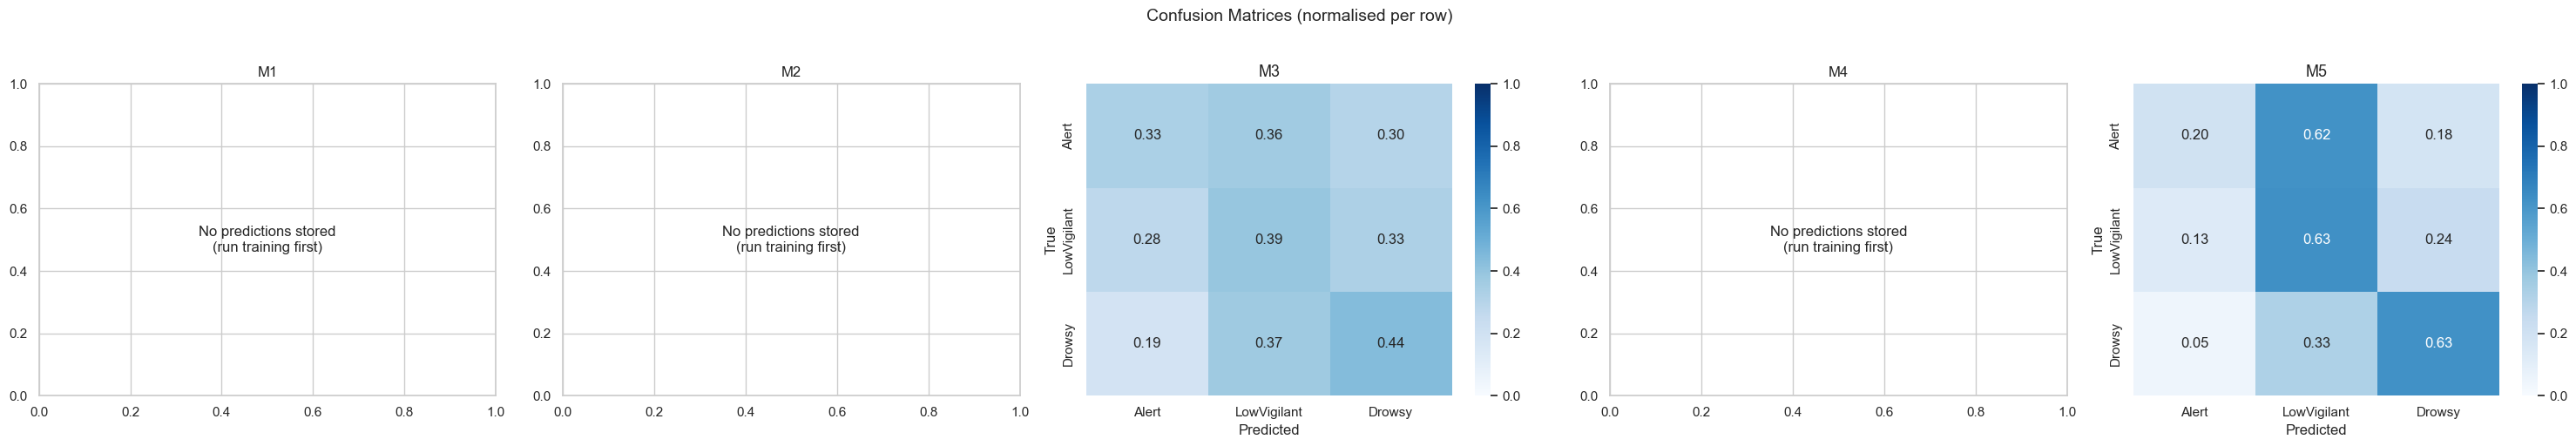

In [6]:
# ── Confusion matrices for all models ────────────────────────────────────────
# Only works if y_true/y_pred were stored during training (store_preds=True)
n_models = len(all_results)
fig, axes = plt.subplots(1, max(1, n_models), figsize=(6*max(1,n_models), 5))

# Normalize axes to iterable
if n_models == 1:
    axes = [axes]

for ax, r in zip(axes, all_results):
    all_true, all_pred = [], []
    for fold in r['folds']:
        if 'y_true' in fold and 'y_pred' in fold:
            all_true.extend(fold['y_true'])
            all_pred.extend(fold['y_pred'])

    if all_true:
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(all_true, all_pred, labels=[0,1,2])
        # Handle possible zero-row sums
        with np.errstate(divide='ignore', invalid='ignore'):
            cm_norm = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True))
        sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    cmap='Blues', vmin=0, vmax=1)
        ax.set_title(r['model_name'], fontsize=13)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    else:
        ax.text(0.5, 0.5, 'No predictions stored\n(run training first)',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(r['model_name'])

plt.suptitle('Confusion Matrices (normalised per row)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# ── Final printed summary ─────────────────────────────────────────────────────
print('='*55)
print(f'{"Model":<10} {"Accuracy":>12} {"Macro-F1":>12}')
print('-'*55)
for r in all_results:
    tag = ' ← proposed' if r['model_name'] == 'M3' else ''
    print(f"{r['model_name']:<10} {r['mean_acc']:>6.4f}±{r['std_acc']:.4f}"
          f" {r['mean_f1']:>6.4f}±{r['std_f1']:.4f}{tag}")
print('='*55)

Model          Accuracy     Macro-F1
-------------------------------------------------------
M1         0.3913±0.1157 0.3475±0.0919
M2         0.3867±0.0401 0.3386±0.0267
M3         0.3992±0.0984 0.3778±0.0934 ← proposed
M4         0.0000±0.0000 0.0000±0.0000
M5         0.5451±0.1000 0.4439±0.0745
